<a href="https://colab.research.google.com/github/Paosososo/movie-recommendation-ensemble/blob/main/Ensemble_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# CELL 1: Install required library and fix NumPy compatibility
!pip install "numpy<2" scikit-surprise

In [ ]:
import os
# List all files in the current directory
print('Current directory:', os.getcwd())
print('Files in current directory:', os.listdir('.'))

# Also check /content just in case
if os.path.exists('/content'):
    print('\nFiles in /content:', os.listdir('/content'))

Current directory: /content
Files in current directory: ['.config', 'movies.dat', 'train.csv', 'python-apt.tar.xz', 'users.dat', 'val.csv', 'sample_data']

Files in /content: ['.config', 'movies.dat', 'train.csv', 'python-apt.tar.xz', 'users.dat', 'val.csv', 'sample_data']


In [ ]:
# CELL 2: Imports and Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import Dataset, Reader, SVD, KNNBasic, NMF
from collections import defaultdict
from tqdm import tqdm # For progress bars

# 1. Load the provided splits
train_df = pd.read_csv('train.csv')
val_df = pd.read_csv('val.csv')

# 2. Load the additional info files (using :: as separator based on README)
movies_df = pd.read_csv('movies.dat', sep='::', engine='python',
                        names=['movie_id', 'title', 'genres'], encoding='latin-1')
users_df = pd.read_csv('users.dat', sep='::', engine='python',
                       names=['user_id', 'gender', 'age', 'occupation', 'zip'], encoding='latin-1')

print("Training data shape:", train_df.shape)
print("Validation data shape:", val_df.shape)
train_df.head()

Training data shape: (987961, 4)
Validation data shape: (6037, 4)


,user_id,movie_id,rating,timestamp
0,1,3186,4,978300019
1,1,1270,5,978300055
2,1,1721,4,978300055
3,1,1022,5,978300055
4,1,2340,3,978300103


/tmp/ipykernel_21036/679893479.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='rating', palette='viridis')
/tmp/ipykernel_21036/679893479.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_movies.index, x=top_movies.values, palette='mako')


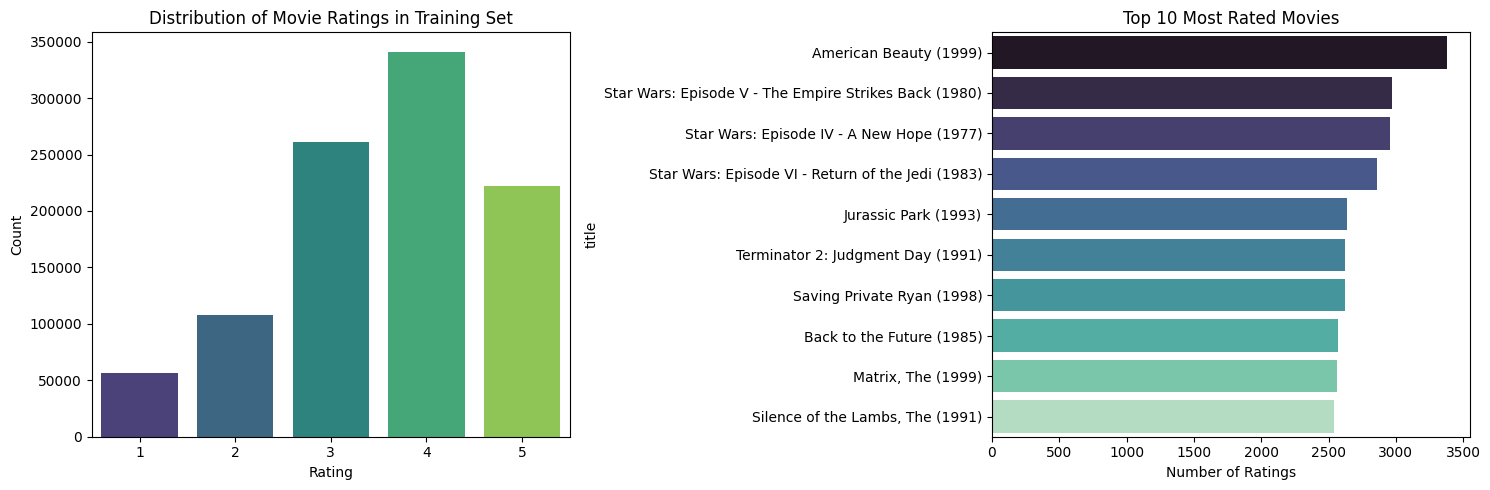

In [ ]:
# CELL 3: Exploratory Data Analysis (EDA)
plt.figure(figsize=(15, 5))

# Plot 1: Distribution of Ratings
plt.subplot(1, 2, 1)
sns.countplot(data=train_df, x='rating', palette='viridis')
plt.title('Distribution of Movie Ratings in Training Set')
plt.xlabel('Rating')
plt.ylabel('Count')

# Plot 2: Top 10 Most Rated Movies
plt.subplot(1, 2, 2)
# Merge to get titles
merged_train = train_df.merge(movies_df, on='movie_id')
top_movies = merged_train['title'].value_counts().head(10)
sns.barplot(y=top_movies.index, x=top_movies.values, palette='mako')
plt.title('Top 10 Most Rated Movies')
plt.xlabel('Number of Ratings')

plt.tight_layout()
plt.show()

In [ ]:
# CELL 4: Preprocessing & Sparsity
# 1. Check for missing values
print("Missing values in train:\n", train_df.isnull().sum())

# 2. Drop timestamp (Not needed for standard Collaborative Filtering)
train_clean = train_df.drop(columns=['timestamp'])
val_clean = val_df.drop(columns=['timestamp'])

# 3. Calculate Matrix Sparsity
num_users = train_clean['user_id'].nunique()
num_movies = train_clean['movie_id'].nunique()
num_ratings = len(train_clean)
sparsity = 1.0 - (num_ratings / (num_users * num_movies))
print(f"\nMatrix Sparsity: {sparsity * 100:.2f}%")
print("This high sparsity means matrix factorization (like SVD) is highly suitable.")

# 4. Prepare data for Surprise Library
reader = Reader(rating_scale=(1, 5))
train_data = Dataset.load_from_df(train_clean[['user_id', 'movie_id', 'rating']], reader)
trainset = train_data.build_full_trainset()

Missing values in train:
 user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

Matrix Sparsity: 95.58%
This high sparsity means matrix factorization (like SVD) is highly suitable.


In [ ]:
# CELL 5: Initialize and Train Models
print("Training SVD...")
algo_svd = SVD(random_state=42)
algo_svd.fit(trainset)

print("Training KNN (Item-Based)...")
# We use item-based cosine similarity
sim_options = {'name': 'cosine', 'user_based': False}
algo_knn = KNNBasic(sim_options=sim_options, random_state=42)
algo_knn.fit(trainset)

print("Training NMF...")
algo_nmf = NMF(random_state=42)
algo_nmf.fit(trainset)

print("All models trained successfully!")

Training SVD...
Training KNN (Item-Based)...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Training NMF...
All models trained successfully!


In [ ]:
# CELL 6: Setup Validation Targets and Candidate Movies

# 1. Get all unique movies in the training set
all_movie_ids = train_clean['movie_id'].unique()

# 2. Map users to the movies they ALREADY rated in training (so we don't recommend them again)
user_history = train_clean.groupby('user_id')['movie_id'].apply(set).to_dict()

# 3. Define the ground truth from validation set
# The requirement implies a relevant movie is one with a rating > 3 (i.e., 4 or 5)
val_relevant = val_clean[val_clean['rating'] > 3]
ground_truth = val_relevant.groupby('user_id')['movie_id'].apply(set).to_dict()

# Users in the validation set to evaluate
val_users = val_clean['user_id'].unique()

print(f"Total Validation Users to evaluate: {len(val_users)}")

Total Validation Users to evaluate: 6037


In [ ]:
# CELL 7: Evaluate Individual Models using Precision@10
def evaluate_model(algo, val_users, all_movies, history, truth):
    precision_scores = []

    # Loop through each user in the validation set
    for uid in tqdm(val_users, desc="Evaluating Users"):
        if uid not in truth:
            continue # Skip users with no relevant movies in validation

        seen_movies = history.get(uid, set())
        predictions = []

        # Predict ratings for all movies the user hasn't seen
        for iid in all_movies:
            if iid not in seen_movies:
                pred = algo.predict(uid, iid).est
                predictions.append((iid, pred))

        # Sort predictions by estimated rating (highest first)
        predictions.sort(key=lambda x: x[1], reverse=True)

        # Get Top 10 recommendations
        top_10 = [iid for iid, _ in predictions[:10]]

        # Calculate Precision@10
        relevant_movies = truth[uid]
        hits = sum(1 for movie in top_10 if movie in relevant_movies)
        precision_scores.append(hits / 10.0)

    return np.mean(precision_scores)

print("\n--- Individual Model Evaluation ---")
svd_score = evaluate_model(algo_svd, val_users, all_movie_ids, user_history, ground_truth)
print(f"\nSVD Precision@10: {svd_score:.4f}")

knn_score = evaluate_model(algo_knn, val_users, all_movie_ids, user_history, ground_truth)
print(f"KNN Precision@10: {knn_score:.4f}")

nmf_score = evaluate_model(algo_nmf, val_users, all_movie_ids, user_history, ground_truth)
print(f"NMF Precision@10: {nmf_score:.4f}")


--- Individual Model Evaluation ---


Evaluating Users: 100%|██████████| 6037/6037 [02:35<00:00, 38.79it/s]



SVD Precision@10: 0.0030


Evaluating Users: 100%|██████████| 6037/6037 [41:40<00:00,  2.41it/s]


KNN Precision@10: 0.0006


Evaluating Users: 100%|██████████| 6037/6037 [01:55<00:00, 52.25it/s]

NMF Precision@10: 0.0005


In [ ]:
# CELL 8: Ensemble Weight Search
print("\n--- Ensemble Weight Optimization ---")

# Define a few weight combinations to test [SVD_weight, KNN_weight, NMF_weight]
weight_grid = [
    [0.4, 0.3, 0.3],
    [0.6, 0.2, 0.2],
    [0.5, 0.4, 0.1],
    [0.8, 0.1, 0.1]
]

best_weights = None
best_score = 0.0

for weights in weight_grid:
    w_svd, w_knn, w_nmf = weights
    precision_scores = []

    for uid in val_users:
        if uid not in ground_truth: continue
        seen_movies = user_history.get(uid, set())
        predictions = []

        for iid in all_movie_ids:
            if iid not in seen_movies:
                # Blend the predictions using the weights
                p_svd = algo_svd.predict(uid, iid).est
                p_knn = algo_knn.predict(uid, iid).est
                p_nmf = algo_nmf.predict(uid, iid).est

                ensemble_pred = (w_svd * p_svd) + (w_knn * p_knn) + (w_nmf * p_nmf)
                predictions.append((iid, ensemble_pred))

        # Sort and get Top 10
        predictions.sort(key=lambda x: x[1], reverse=True)
        top_10 = [iid for iid, _ in predictions[:10]]

        # Calculate score
        hits = sum(1 for movie in top_10 if movie in ground_truth[uid])
        precision_scores.append(hits / 10.0)

    avg_score = np.mean(precision_scores)
    print(f"Weights {weights} -> Precision@10: {avg_score:.4f}")

    if avg_score > best_score:
        best_score = avg_score
        best_weights = weights

print(f"\nBest Weights Found: {best_weights} with Score: {best_score:.4f}")


--- Ensemble Weight Optimization ---
Weights [0.4, 0.3, 0.3] -> Precision@10: 0.0025
Weights [0.6, 0.2, 0.2] -> Precision@10: 0.0029
Weights [0.5, 0.4, 0.1] -> Precision@10: 0.0033
Weights [0.8, 0.1, 0.1] -> Precision@10: 0.0029

Best Weights Found: [0.5, 0.4, 0.1] with Score: 0.0033


In [ ]:
# CELL 9: Generate Final Outputs
final_recommendations = []
w_svd, w_knn, w_nmf = best_weights

print("Generating final recommendation lists for output file...")

for uid in tqdm(val_users, desc="Writing to CSV"):
    seen_movies = user_history.get(uid, set())
    predictions = []

    for iid in all_movie_ids:
        if iid not in seen_movies:
            p_svd = algo_svd.predict(uid, iid).est
            p_knn = algo_knn.predict(uid, iid).est
            p_nmf = algo_nmf.predict(uid, iid).est

            ensemble_pred = (w_svd * p_svd) + (w_knn * p_knn) + (w_nmf * p_nmf)
            predictions.append((iid, ensemble_pred))

    # Sort and slice top 10
    predictions.sort(key=lambda x: x[1], reverse=True)
    top_10 = [str(iid) for iid, _ in predictions[:10]]

    # Format as comma-separated string
    movies_str = ", ".join(top_10)
    final_recommendations.append({'user_id': uid, 'recommended_movies': movies_str})

# Create DataFrame and export
output_df = pd.DataFrame(final_recommendations)
output_df.to_csv('output.csv', index=False)
print("\nSuccess! 'output.csv' has been generated and is ready for submission.")
output_df.head()

Generating final recommendation lists for output file...


Writing to CSV: 100%|██████████| 6037/6037 [48:40<00:00,  2.07it/s]


Success! 'output.csv' has been generated and is ready for submission.


,user_id,recommended_movies
0,1,"2905, 904, 1198, 318, 1262, 1148, 858, 2019, 1..."
1,2,"260, 527, 1704, 3382, 2324, 2762, 1097, 1148, ..."
2,3,"110, 318, 2324, 527, 3578, 2329, 2905, 1262, 2..."
3,4,"2905, 745, 527, 1203, 3114, 720, 3338, 1148, 3..."
4,5,"1244, 1136, 1288, 750, 2019, 1230, 111, 922, 9..."
